#Importações das duas bases de dados

In [ ]:
import pandas as pd

urlAntra = "https://docs.google.com/spreadsheets/d/1TFWT3znWcXrEbT1E97vIX8heNwuRllAj5t24ejAigpw/export?format=csv&gid=0"

dfAntra = pd.read_csv(urlAntra)
dfAntra.head()

,id,siglaUf,regiao,ano,qtdTransicidios
0,0,AC,Norte,2018,0
1,1,AL,Nordeste,2018,3
2,2,AM,Norte,2018,6
3,3,AP,Norte,2018,0
4,4,BA,Nordeste,2018,15


In [ ]:
urlFemEst = "https://docs.google.com/spreadsheets/d/1gszLopNA8KTm_gYM74chP5qJObrmePW1EfIc9Y8zCdE/export?format=csv&gid=333555222"

dfFemEst = pd.read_csv(urlFemEst)
dfFemEst.head()

,id,siglaUf,regiao,ano,qtdFeminicidio
0,0,AC,Norte,2018,5
1,1,AL,Nordeste,2018,7
2,2,AM,Norte,2018,3
3,3,AP,Norte,2018,2
4,4,BA,Nordeste,2018,7


In [ ]:
# Abaixo, agrupei os dados relevantes para a análise por região e ano em cada base #

In [ ]:
dfAntraRegiaoAno = (
    dfAntra
    .groupby(['regiao', 'ano'], as_index=False)
    .agg({
        'qtdTransicidios': 'sum'
        })
                  )
dfAntraRegiaoAno.head(10)

,regiao,ano,qtdTransicidios
0,Centro-Oeste,2018,18
1,Centro-Oeste,2019,12
2,Centro-Oeste,2020,12
3,Centro-Oeste,2021,15
4,Nordeste,2018,59
5,Nordeste,2019,45
6,Nordeste,2020,75
7,Nordeste,2021,47
8,Norte,2018,19
9,Norte,2019,14


In [ ]:
dfFemEstRegiaoAno = (
    dfFemEst
    .groupby(['regiao', 'ano'], as_index=False)
    .agg({
        'qtdFeminicidio': 'sum'
        })
                    )

dfFemEstRegiaoAno.head(10)

,regiao,ano,qtdFeminicidio
0,Centro-Oeste,2018,54
1,Centro-Oeste,2019,38
2,Centro-Oeste,2020,43
3,Centro-Oeste,2021,36
4,Nordeste,2018,55
5,Nordeste,2019,61
6,Nordeste,2020,61
7,Nordeste,2021,65
8,Norte,2018,27
9,Norte,2019,32


In [ ]:
# Merge das duas bases para análise de região #
dfAnaliseRegiao = pd.merge(
    dfAntraRegiaoAno,
    dfFemEstRegiaoAno,
    on=['regiao', 'ano'],
    how='inner'
                    )
dfAnaliseRegiao.head(10)

,regiao,ano,qtdTransicidios,qtdFeminicidio
0,Centro-Oeste,2018,18,54
1,Centro-Oeste,2019,12,38
2,Centro-Oeste,2020,12,43
3,Centro-Oeste,2021,15,36
4,Nordeste,2018,59,55
5,Nordeste,2019,45,61
6,Nordeste,2020,75,61
7,Nordeste,2021,47,65
8,Norte,2018,19,27
9,Norte,2019,14,32


#Criação do Índice Relacional entre Transicídios e Feminicídios

In [ ]:
dfAnaliseRegiao['indiceRelacional'] = (
    dfAnaliseRegiao['qtdTransicidios'] / dfAnaliseRegiao['qtdFeminicidio']
                                )
dfAnaliseRegiao.head(10)

,regiao,ano,qtdTransicidios,qtdFeminicidio,indiceRelacional
0,Centro-Oeste,2018,18,54,0.333333
1,Centro-Oeste,2019,12,38,0.315789
2,Centro-Oeste,2020,12,43,0.279070
3,Centro-Oeste,2021,15,36,0.416667
4,Nordeste,2018,59,55,1.072727
5,Nordeste,2019,45,61,0.737705
6,Nordeste,2020,75,61,1.229508
7,Nordeste,2021,47,65,0.723077
8,Norte,2018,19,27,0.703704
9,Norte,2019,14,32,0.437500


In [ ]:
# O índice relacional acima expressa a relação entre dois registros de violência letal de gênero, permitindo identificar padrões territoriais e temporais sem pressupor equivalência categorial. #
# Um índice alto significa que, proporcionalmente aos assassinatos de mulheres cisgênero, aquela região está matando pessoas trans em um ritmo acelerado e desproporcional #

#Criação de Z-Score do Índice Relacional entre Feminicídios e Transicídios

In [ ]:
dfAnaliseRegiao['zIndiceRelacional'] = (
    dfAnaliseRegiao
    .groupby('ano')['indiceRelacional']
    .transform(lambda x: (x - x.mean()) / x.std())
                                       )
dfAnaliseRegiao.head(10)

,regiao,ano,qtdTransicidios,qtdFeminicidio,indiceRelacional,zIndiceRelacional
0,Centro-Oeste,2018,18,54,0.333333,-1.349297
1,Centro-Oeste,2019,12,38,0.315789,-0.799073
2,Centro-Oeste,2020,12,43,0.279070,-0.970910
3,Centro-Oeste,2021,15,36,0.416667,-0.816930
4,Nordeste,2018,59,55,1.072727,1.423283
5,Nordeste,2019,45,61,0.737705,0.162801
6,Nordeste,2020,75,61,1.229508,1.525670
7,Nordeste,2021,47,65,0.723077,1.074649
8,Norte,2018,19,27,0.703704,0.039518
9,Norte,2019,14,32,0.437500,-0.521600


In [ ]:
# No dataframe acima, zIndiceRelacional > 0 indica que a região tem mais transicídios relativamente aos feminicídios do que a média nacional daquele ano, logo maior vulnerabilidade relativa para pessoas transfemininas. #
# Se z < 0 a região tem menos transicídios relativamente aos feminicídios do que a média nacional daquele ano, logo, menor vulnerabilidade relativa para pessoas transfemininas #

#Gráficos Temporais por Região (Linha do Tempo)

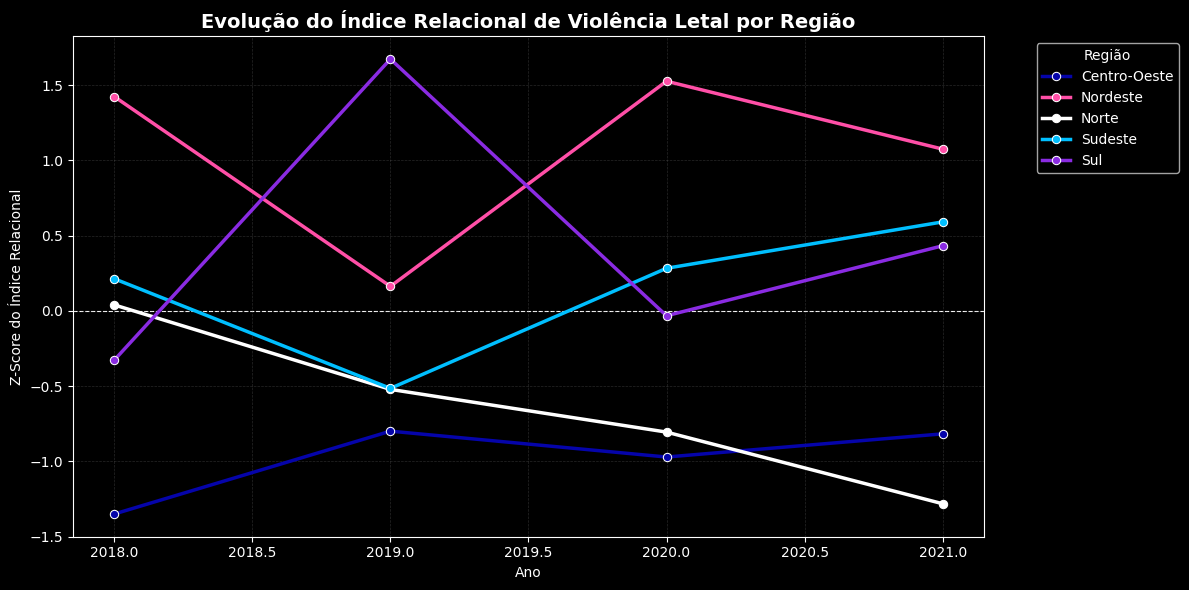

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

coresEscolhidas = {
    'Norte': '#FFFFFF',
    'Nordeste': '#FF4FA7',
    'Centro-Oeste': '#0504AA',
    'Sudeste': '#00BFFF',
    'Sul': '#8A2BE2'
                  }

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=dfAnaliseRegiao,
    x='ano',
    y='zIndiceRelacional',
    hue='regiao',
    marker='o',
    palette=coresEscolhidas,
    linewidth=2.5
            )

plt.axhline(0, color='white', linestyle='--', linewidth=0.8, zorder=0)

plt.title('Evolução do Índice Relacional de Violência Letal por Região', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Z-Score do Índice Relacional', color='white')
plt.xlabel('Ano', color='white')

plt.legend(title='Região', frameon=True, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
# No gráfico acima o z-score do índice relacional permite comparação direta, independente do tamanho absoluto da região #

#Gráficos Temporais com Regressão

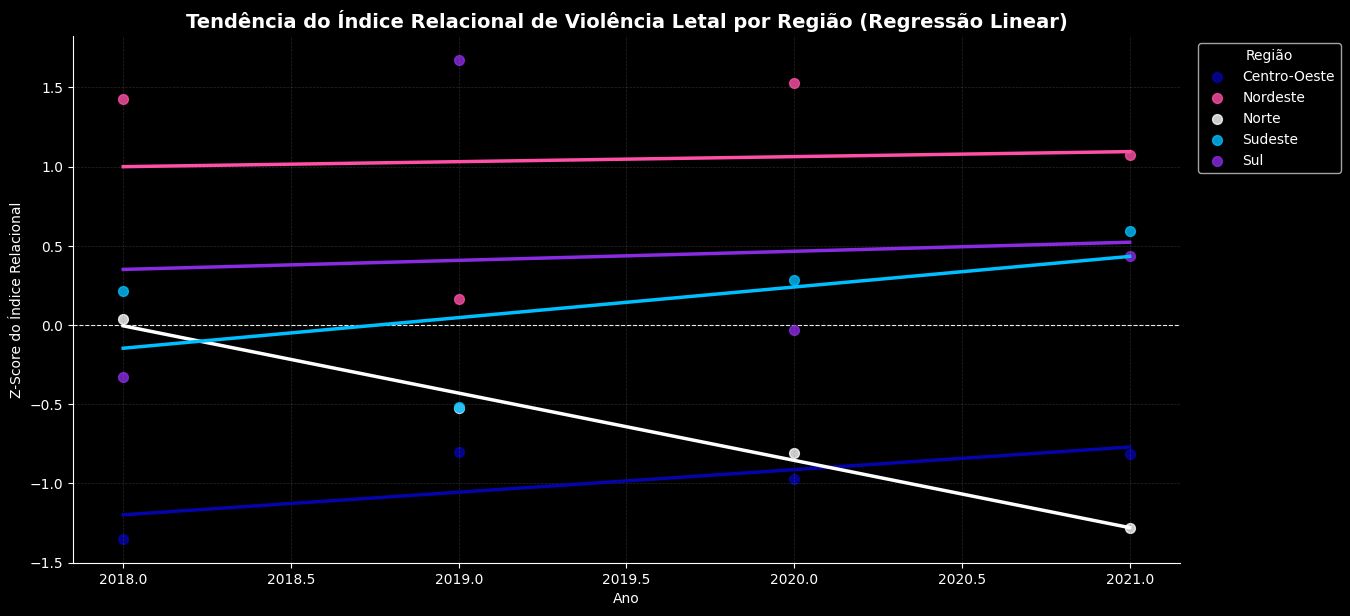

In [ ]:
plt.style.use("dark_background")

coresEscolhidas2 = {
    'Norte': '#FFFFFF',
    'Nordeste': '#FF4FA7',
    'Centro-Oeste': '#0504AA',
    'Sudeste': '#00BFFF',
    'Sul': '#8A2BE2'
                   }

sns.lmplot(
    data=dfAnaliseRegiao,
    x='ano',
    y='zIndiceRelacional',
    hue='regiao',
    markers='o',
    height=6,
    aspect=2,
    ci=None,
    palette=coresEscolhidas,
    legend=False,
    scatter_kws={'s': 50},
    line_kws={'linewidth': 2.5}
          )

plt.axhline(0, color='white', linestyle='--', linewidth=0.8, zorder=0)

plt.title('Tendência do Índice Relacional de Violência Letal por Região (Regressão Linear)', fontsize=14, fontweight='bold', color='white')
plt.ylabel('Z-Score do Índice Relacional', color='white')
plt.xlabel('Ano', color='white')

plt.legend(title='Região', frameon=True, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

plt.show()

In [ ]:
import numpy as np

# Agrupa por região e calcula a regressão linear (grau 1)
# O resultado [0] é o coeficiente angular (a inclinação da reta)
dfTendencias = dfAnaliseRegiao.groupby('regiao').apply(
    lambda x: np.polyfit(x['ano'], x['zIndiceRelacional'], 1)[0]
    ).reset_index(name='coeficiente')

dfTendencias

/tmp/ipython-input-2726762185.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfTendencias = dfAnaliseRegiao.groupby('regiao').apply(


,regiao,coeficiente
0,Centro-Oeste,0.142526
1,Nordeste,0.031697
2,Norte,-0.424584
3,Sudeste,0.193149
4,Sul,0.057212


#Ranking de Periculosidade Estática por Região

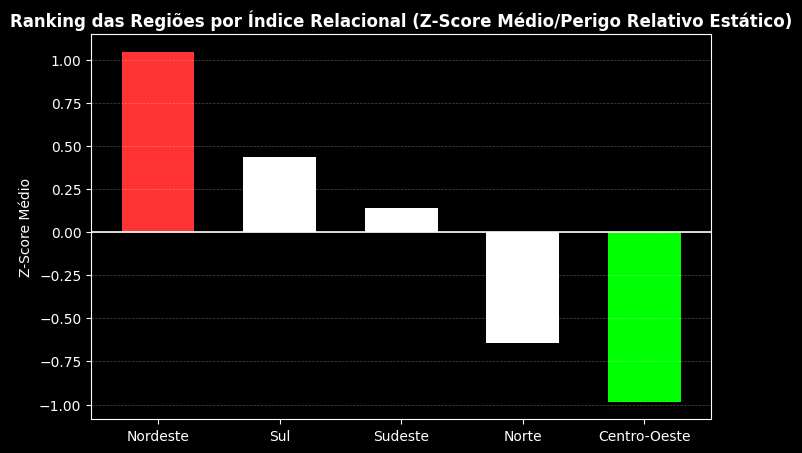

,regiao,zIndiceRelacional
0,Nordeste,1.046600
1,Sul,0.436530
2,Sudeste,0.143071
3,Norte,-0.642149
4,Centro-Oeste,-0.984052


In [ ]:
# Média por região #
dfRankingRegiao = dfAnaliseRegiao.groupby('regiao')['zIndiceRelacional'].mean().sort_values(ascending=False)

plt.style.use("dark_background")

coresBarras = []
maxValor = dfRankingRegiao.max()
minValor = dfRankingRegiao.min()

for valor in dfRankingRegiao:
    if valor == maxValor:
        coresBarras.append('#FF3333')
    elif valor == minValor:
        coresBarras.append('#00FF00')
    else:
        coresBarras.append('#FFFFFF')

plt.figure(figsize=(8, 5))

dfRankingRegiao.plot(kind='bar', color=coresBarras, width=0.6)

plt.axhline(0, color='white', linewidth=1.2)

plt.title('Ranking das Regiões por Índice Relacional (Z-Score Médio/Perigo Relativo Estático)', fontsize=12, fontweight='bold', color='white')
plt.ylabel('Z-Score Médio', color='white')
plt.xlabel('')

plt.xticks(rotation=0, color='white')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

plt.show()

dfRankingRegiao = dfRankingRegiao.reset_index()

dfRankingRegiao

In [ ]:
# Acima, a região mais consistentemente acima da média nacional é a região Nordeste, portanto é a região historicamente mais perigosa. #
# Enquanto a região mais consistentemente abaixo da média nacional é a região Centro-Oeste, portanto é a região historicamente mais segura (Medidas de intensidade acumuladas/Histórico relativo) #

#Ranking de Periculosidade Estática por Estado das Regiões Mais Perigosa e Menos Perigosa


In [ ]:
# Novo merge com estados (siglaUf) #
dfAnaliseEstados = pd.merge(
    dfAntra,
    dfFemEst,
    on=['id', 'siglaUf', 'regiao', 'ano'],
    how='inner'
                           )

# Índice relacional #
dfAnaliseEstados['indiceRelacional'] = dfAnaliseEstados['qtdTransicidios'] / dfAnaliseEstados['qtdFeminicidio']

# Z-score por ano #
dfAnaliseEstados['zIndiceRelacional'] = dfAnaliseEstados.groupby('ano')['indiceRelacional'].transform(lambda x: (x - x.mean()) / x.std())

dfAnaliseEstados.head()


,id,siglaUf,regiao,ano,qtdTransicidios,qtdFeminicidio,indiceRelacional,zIndiceRelacional
0,0,AC,Norte,2018,0,5,0.000000,-1.174882
1,1,AL,Nordeste,2018,3,7,0.428571,-0.627099
2,2,AM,Norte,2018,6,3,2.000000,1.381439
3,3,AP,Norte,2018,0,2,0.000000,-1.174882
4,4,BA,Nordeste,2018,15,7,2.142857,1.564033


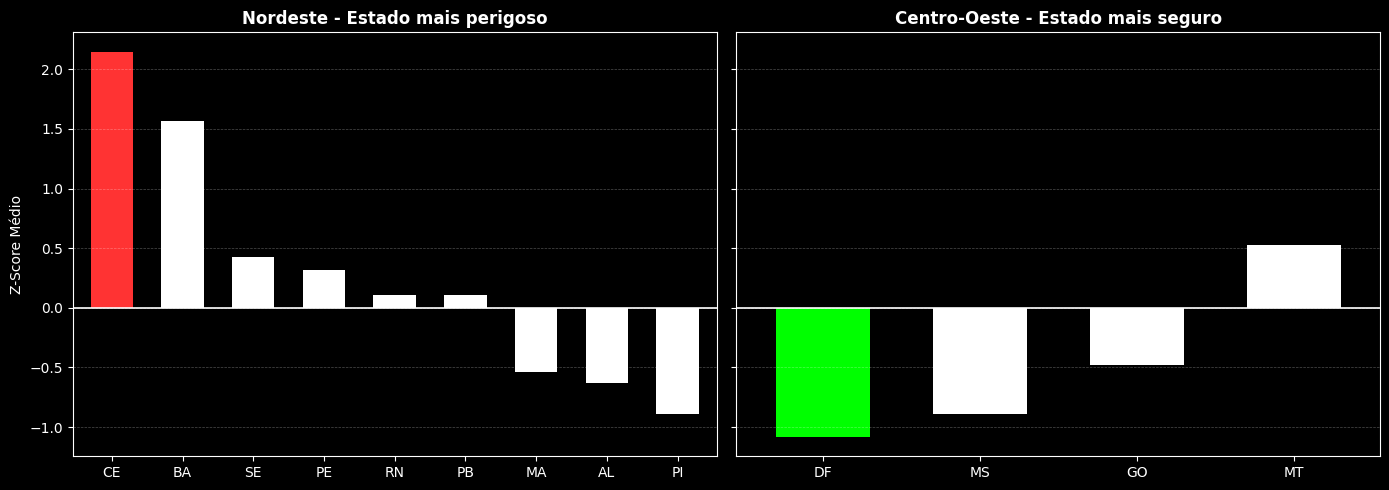

,siglaUf,zIndiceRelacional
0,CE,2.148335
1,BA,1.564033
2,SE,0.422819
3,PE,0.316305
4,RN,0.103279
5,PB,0.103279
6,MA,-0.535801
7,AL,-0.627099
8,PI,-0.890846


In [ ]:
# Filtro das regiões específicas #
dfNordeste = dfAnaliseEstados[dfAnaliseEstados['regiao'] == 'Nordeste']
dfCentroOeste = dfAnaliseEstados[dfAnaliseEstados['regiao'] == 'Centro-Oeste']

# Ranking por estado dentro da região #
dfRankingNordeste = dfNordeste.groupby('siglaUf')['zIndiceRelacional'].mean().sort_values(ascending=False)
dfRankingCentroOeste = dfCentroOeste.groupby('siglaUf')['zIndiceRelacional'].mean().sort_values()

# Nordeste - mais perigosa #
coresNordeste = ['#FF3333' if valor == dfRankingNordeste.max() else '#FFFFFF' for valor in dfRankingNordeste]

# Centro-Oeste - mais segura #
coresCentroOeste = ['#00FF00' if valor == dfRankingCentroOeste.min() else '#FFFFFF' for valor in dfRankingCentroOeste]
plt.style.use("dark_background")
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Nordeste #
dfRankingNordeste.plot(kind='bar', color=coresNordeste, width=0.6, ax=axs[0])
axs[0].axhline(0, color='white', linewidth=1.2)
axs[0].set_title('Nordeste - Estado mais perigoso', fontsize=12, fontweight='bold', color='white')
axs[0].set_ylabel('Z-Score Médio', color='white')
axs[0].set_xlabel('')
axs[0].tick_params(axis='x', rotation=0, colors='white')
axs[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

# Centro-Oeste #
dfRankingCentroOeste.plot(kind='bar', color=coresCentroOeste, width=0.6, ax=axs[1])
axs[1].axhline(0, color='white', linewidth=1.2)
axs[1].set_title('Centro-Oeste - Estado mais seguro', fontsize=12, fontweight='bold', color='white')
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].tick_params(axis='x', rotation=0, colors='white')
axs[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

dfRankingNordeste = dfRankingNordeste.reset_index()
dfRankingNordeste

In [ ]:
dfRankingCentroOeste = dfRankingCentroOeste.reset_index()
dfRankingCentroOeste

,siglaUf,zIndiceRelacional
0,DF,-1.083584
1,MS,-0.890846
2,GO,-0.477703
3,MT,0.529332


In [ ]:
# ↑ Conforme a análise acima, o Ceará dispara como o estado mais perigoso dentro da região mais perigosa (Nordeste), enquanto o Distrito Federal é a unidade federativa mais segura dentro da região mais segura (Centro-Oeste) ↑ #

#Ranking de Periculosidade Estática e Tendência por Região

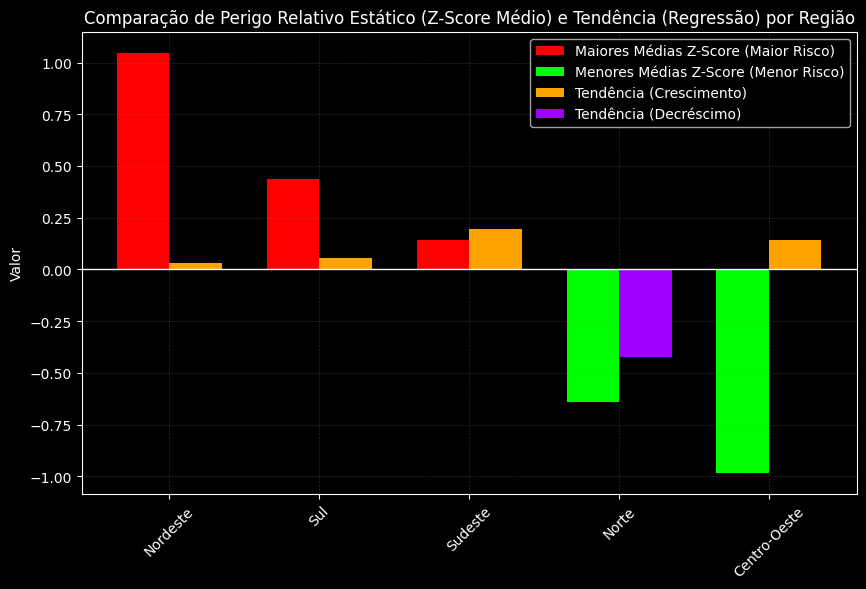

,regiao,zMedio,coefTend
0,Nordeste,1.046600,0.031697
1,Sul,0.436530,0.057212
2,Sudeste,0.143071,0.193149
3,Norte,-0.642149,-0.424584
4,Centro-Oeste,-0.984052,0.142526


In [ ]:
from matplotlib.patches import Patch
from sklearn.linear_model import LinearRegression

# Ranking por índice relacional #
dfRankingMedia = dfAnaliseRegiao.groupby('regiao')['zIndiceRelacional'].mean().sort_values(ascending=False)
dfRankingMedia = dfRankingMedia.reset_index()
dfRankingMedia.rename(columns={'zIndiceRelacional': 'zMedio'}, inplace=True)

# Ranking por coeficiente da regressão (tendência temporal) #
listaRegioes = dfAnaliseRegiao['regiao'].unique()
listaCoeficientes = []

for regiaoAtual in listaRegioes:
    dfTemp = dfAnaliseRegiao[dfAnaliseRegiao['regiao'] == regiaoAtual]
    X = dfTemp['ano'].values.reshape(-1,1)
    y = dfTemp['zIndiceRelacional'].values
    modeloLinear = LinearRegression()
    modeloLinear.fit(X, y)
    listaCoeficientes.append({'regiao': regiaoAtual, 'coefTend': modeloLinear.coef_[0]})

rankingTendencia = pd.DataFrame(listaCoeficientes).sort_values('coefTend', ascending=False)

# Merge para plot lado a lado #
dfRankingFinal = pd.merge(dfRankingMedia, rankingTendencia, on='regiao')

coresZScore = []
maxZ = dfRankingFinal['zMedio'].max()

for valor in dfRankingFinal['zMedio']:
    if valor > 0:
        coresZScore.append('#FF0000') # Vermelho para valores positivos #
    elif valor < 0:
        coresZScore.append('#00FF00') # Verde neon para negativos #

coresTendencia = []
minT = dfRankingFinal['coefTend'].min()

for valor in dfRankingFinal['coefTend']:
    if valor == minT:
        coresTendencia.append('#9D00FF') # Roxo para o menor valor #
    else:
        coresTendencia.append('#FDA300') # Amarelo para os demais #

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(10,6))

ax.axhline(0, color='white', linestyle='-', linewidth=1, zorder=3)

barWidth = 0.35
indices = np.arange(len(dfRankingFinal))

ax.bar(indices - barWidth/2, dfRankingFinal['zMedio'], barWidth, label='Média Z-Score', color=coresZScore, zorder=1)
ax.bar(indices + barWidth/2, dfRankingFinal['coefTend'], barWidth, label='Tendência', color=coresTendencia, zorder=2)

ax.set_xticks(indices)
ax.set_xticklabels(dfRankingFinal['regiao'], rotation=45)
ax.set_ylabel('Valor')
ax.set_title('Comparação de Perigo Relativo Estático (Z-Score Médio) e Tendência (Regressão) por Região')

elementosLegenda = [Patch(facecolor='#FF0000', label='Maiores Médias Z-Score (Maior Risco)'),
                    Patch(facecolor='#00FF00', label='Menores Médias Z-Score (Menor Risco)'),
                    Patch(facecolor='#FDA300', label='Tendência (Crescimento)'),
                    Patch(facecolor='#9D00FF', label='Tendência (Decréscimo)')
                   ]
ax.legend(handles=elementosLegenda)

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3, zorder=0)
plt.show()

dfRankingFinal

In [ ]:
# ↑ Caso a tendência observada se mantenha, o Norte apresenta potencial de se tornar a região relativamente mais segura no médio prazo ↑ #

#Salvamento dos Dataframes Principais

In [ ]:
dfAnaliseRegiao.to_csv("analise_regiao.csv", index=False, sep=',', decimal='.')
dfRankingRegiao.to_csv("ranking_regiao.csv", index=False, sep=',', decimal='.')
dfRankingNordeste.to_csv("ranking_nordeste.csv", index=False, sep=',', decimal='.')
dfRankingCentroOeste.to_csv("ranking_centro_oeste.csv", index=False, sep=',', decimal='.')
dfRankingFinal.to_csv("ranking_final.csv", index=False, sep=',', decimal='.')
dfTendencias.to_csv("tendencias_regiao.csv", index=False, sep=',', decimal='.')